# Dugong Dataset: Comprehensive Strategic Analysis

|  |  |
| ----------- | ----------- |
| Author:| Karishma Khanna |
| Affiliation:| AODN / NESP |
| e-mail:| karishma.khanna@utas.edu.au |
| Date of creation:| 2026-03-17 |
| Date of last update:| 2026-03-18 |


## Background & Objectives

### What is the Dugong Dataset?
The Dugong Dataset is an aggregated occurrence data product compiled from multi-platform survey records (including vessel-based, aerial, and shore-based surveys) of dugong populations across Australian waters. The underlying ETL pipeline has explicitly unrolled aggregated group counts, meaning each row structurally represents a distinct biological life stage (e.g., discrete adult and calf occurrence records).

**Objective:** This notebook provides a strategic analysis of dugong population distribution, demographics, and spatial patterns across key Australian marine habitats.

| Parameter | Details |
| :--- | :--- |
| **Species** | *Dugong dugon* |
| **Coverage** | Australian Coastal & Marine Waters |
| **Source** | NESP Multi-Platform Surveys |
| **Source Status** | Optimised (ETL Validated) |
| **Format** | Parquet (S3) |

**Key Analytical Modules:**
1. **Population Demographics:** Calf-to-adult ratios as breeding success indicators
2. **Temporal Trends:** Year-over-year sighting patterns
3. **Monthly Survey Distribution:** Seasonality of survey effort across years
4. **Survey Conditions:** Data quality context through Beaufort scale & turbidity
5. **Spatial Density Mapping:** High-resolution H3 hexagonal heatmaps
6. **Habitat Distribution:** Population densities across marine regions

### Required Packages

- polars
- pandas
- pydeck
- matplotlib
- h3
- IPython

In [1]:
# Data Processing
import polars as pl
import polars_h3
import pandas as pd
import math

# AWS & Geospatial
import pyarrow
import pyarrow.fs
import pyarrow.dataset
import pydeck as pdk
import h3

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Utilities
import IPython.display
import util

# Configure a clean, executive style for visualisations
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Loading the Dataset
The analysis initiates by loading the optimised master Parquet dataset from S3 storage.

In [2]:
# Construct the anonymous file system responsible for reading from the public S3 bucket
FILE_SYSTEM = pyarrow.fs.S3FileSystem(
    region="ap-southeast-2", 
    anonymous=True,
)

# Create the dataset connection
ds = pyarrow.dataset.dataset(
    source="data-uplift-public/stored/datauplift/dugong/dugong.parquet",
    filesystem=FILE_SYSTEM,
)

# The comprising files of the dataset can be inspected
print(f"Dataset fragments: {list(ds.get_fragments())}")

# The schema of the dataset can be inspected
util.print_schema_rich_table(
    schema=ds.schema,
    metadata_keys=["definition", "units", "long_name", "resolution"]
)

# Load into polars DataFrame
df = pl.DataFrame(data=ds.to_table())

# Estimate dataset size
estimated_megabytes = util.estimate_dataset_size(
    ds=ds,
    n_samples=10_000,
)
print(f"DS estimated size: {round(estimated_megabytes, 2)}MB")
print(f"Successfully loaded {df.height} occurrence records.")

Dataset fragments: [<pyarrow.dataset.ParquetFileFragment path=data-uplift-public/stored/datauplift/dugong/dugong.parquet>]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ name                        ┃ type   ┃ definition                 ┃ units ┃ long_name              ┃ resolution ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ eventID                     │ string │ An identifier for the set  │       │ Event ID               │            │
│                             │        │ of information associated  │       │                        │            │
│                             │        │ with a dwc:Event           │       │                        │            │
│                             │        │ (something that occurs at  │       │                        │            │
│                             │        │ a place and time). May be  │       │                        │            │
│                             │        │ a global unique identifier │       │                        │            │
│                             │        │ or an identifier specific  │       │                        │            │
│                             │        │ to the data set.           │       │                        │            │
├─────────────────────────────┼────────┼────────────────────────────┼───────┼────────────────────────┼────────────┤
│ occurrenceID                │ string │ An identifier for the      │       │ Occurrence ID          │            │
│                             │        │ dwc:Occurrence (as opposed │       │                        │            │
│                             │        │ to a particular digital    │       │                        │            │
│                             │        │ record of the              │       │                        │            │
│                             │        │ dwc:Occurrence). In the    │       │                        │            │
│                             │        │ absence of a persistent    │       │                        │            │
│                             │        │ global unique identifier,  │       │                        │            │
│                             │        │ construct one from a       │       │                        │            │
│                             │        │ combination of identifiers │       │                        │            │
│                             │        │ in the record that will    │       │                        │            │
│                             │        │ most closely make the      │       │                        │            │
│                             │        │ dwc:occurrenceID globally  │       │                        │            │
│                             │        │ unique.                    │       │                        │            │
├─────────────────────────────┼────────┼────────────────────────────┼───────┼────────────────────────┼────────────┤
│ recordNumber                │ int64  │ An identifier given to the │       │ Record Number          │            │
│                             │        │ dwc:Occurrence at the time │       │                        │            │
│                             │        │ it was recorded. Often     │       │                        │            │
│                             │        │ serves as a link between   │       │                        │            │
│                             │        │ field notes and a          │       │                        │            │
│                             │        │ dwc:Occurrence record,     │       │                        │            │
│                             │        │ such as a specimen         │       │                        │            │
│                             │        │ collector's number.        │       │                        │            │
├─────────────────────────────┼────────┼────────────────

DS estimated size: 3.63MB
Successfully loaded 9628 occurrence records.


## 2. Population Demographics
The ratio of calves to adults is a primary indicator of population recovery and breeding success in dugong populations. This dataset distinguishes between adult and calf sightings, enabling direct analysis of demographic composition and reproductive health indicators.

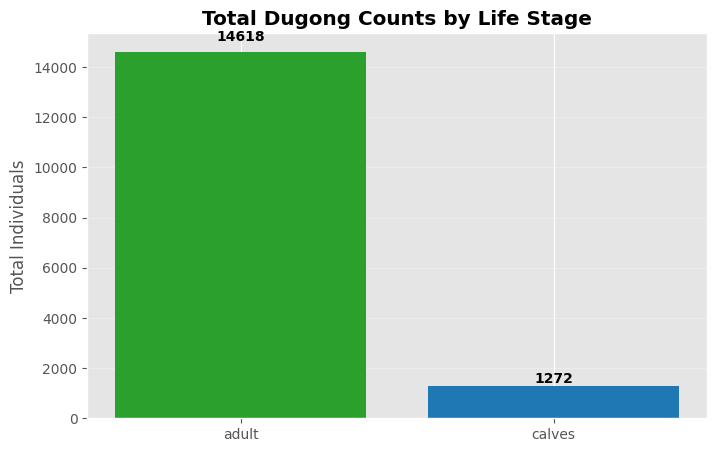

In [3]:
demographics = (
    df.filter(pl.col("organismQuantityType").is_in(["adult", "calves"]))
    .group_by("organismQuantityType")
    .agg(pl.col("organismQuantity").sum().alias("total_count"))
    .sort("total_count", descending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    demographics["organismQuantityType"].to_list(), 
    demographics["total_count"].to_list(),
    color=['#2ca02c', '#1f77b4']
)

ax.set_title("Total Dugong Counts by Life Stage", fontweight='bold')
ax.set_ylabel("Total Individuals")
plt.grid(axis='y', alpha=0.3)

# Add Value Labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), ha='center', va='bottom', fontweight='bold')

plt.show()

## 3. Temporal Trends & Recruitment Patterns
A primary indicator of population stability is the ratio of calves to adults. The following aggregation tracks sighting totals over time, segmented by life stage. This provides researchers with a baseline metric for monitoring breeding success and recruitment rates across survey years.

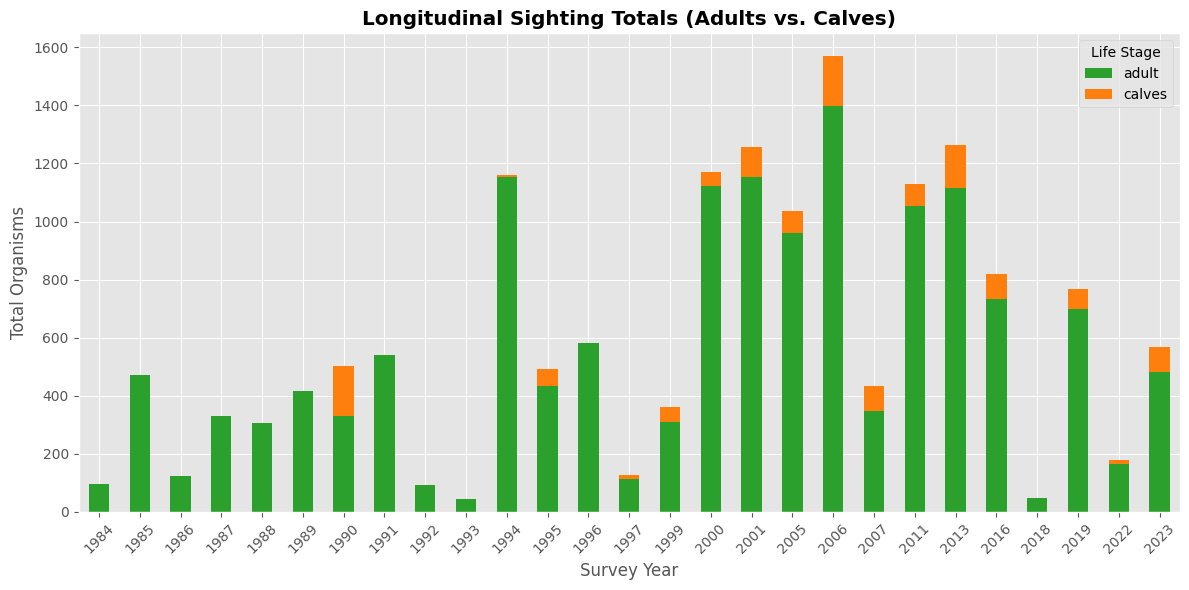

In [4]:
yearly_trends = (
    df.with_columns(pl.col("eventDate").dt.year().alias("Year"))
    .filter(pl.col("organismQuantityType").is_in(["adult", "calves"]))
    .group_by(["Year", "organismQuantityType"])
    .agg(pl.col("organismQuantity").sum().alias("total"))
    .drop_nulls("Year")
    .sort("Year")
    .to_pandas()
)

# Pivot the data for a structured stacked bar visualization
pivot_trends = yearly_trends.pivot(index="Year", columns="organismQuantityType", values="total").fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_trends.plot(kind='bar', stacked=True, color=['#2ca02c', '#ff7f0e'], ax=ax)

ax.set_title("Longitudinal Sighting Totals (Adults vs. Calves)", fontweight='bold')
ax.set_ylabel("Total Organisms")
ax.set_xlabel("Survey Year")
plt.xticks(rotation=45)
plt.legend(title="Life Stage")
plt.tight_layout()
plt.show()

## 4. Monthly Survey Distribution
This section examines the seasonality of dugong surveys aggregated across all years. The bar chart below illustrates which months have historically had the highest survey effort, providing context for interpreting temporal population patterns.

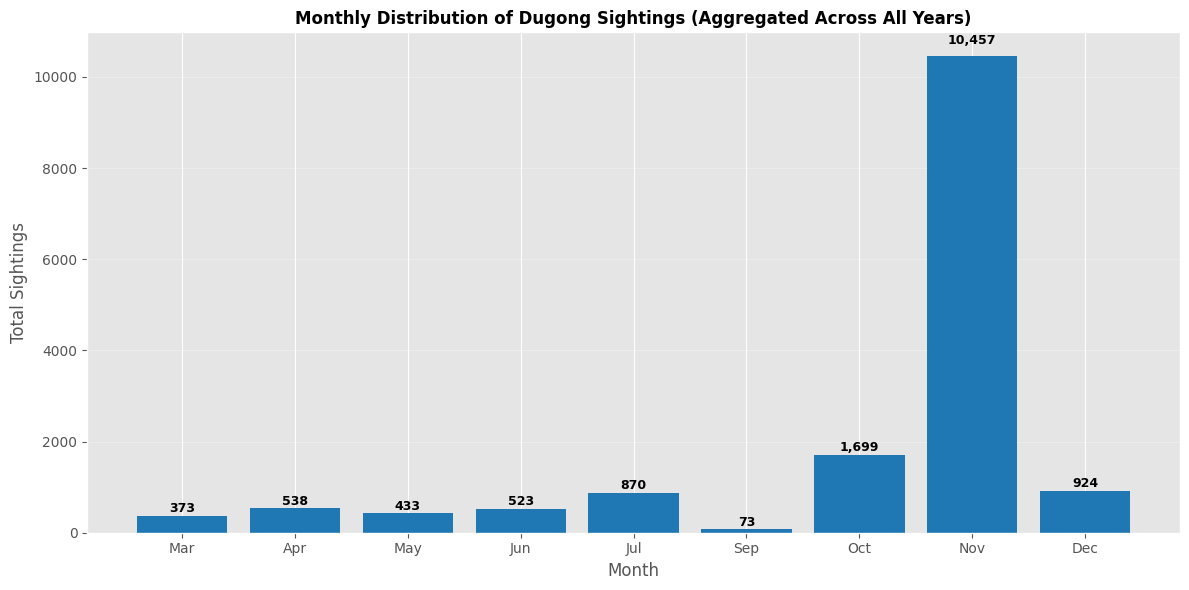

In [5]:
# Monthly distribution of sightings across all survey years
monthly_counts = (
    df.with_columns(pl.col("eventDate").dt.month().alias("Month"))
    .drop_nulls("Month")
    .group_by("Month")
    .agg(pl.col("organismQuantity").sum().alias("total_sightings"))
    .sort("Month")
    .to_pandas()
)

# Map month numbers to names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_counts['Month_Name'] = monthly_counts['Month'].map(month_names)

# Create bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    monthly_counts['Month_Name'],
    monthly_counts['total_sightings'],
    color='#1f77b4'
)

ax.set_title("Monthly Distribution of Dugong Sightings (Aggregated Across All Years)", fontweight='bold', fontsize=12)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sightings")
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), f'{int(yval):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Survey Conditions Analysis
Understanding the environmental conditions during surveys is critical for data quality assessment. The Beaufort Scale measures sea state (0 = calm, 6+ = rough), while turbidity indicates water clarity. Lower values in both metrics generally indicate better sighting conditions.

C:\Users\khannak\AppData\Local\Temp\ipykernel_38216\2990319464.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))
C:\Users\khannak\AppData\Local\Temp\ipykernel_38216\2990319464.py:32: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("count"))


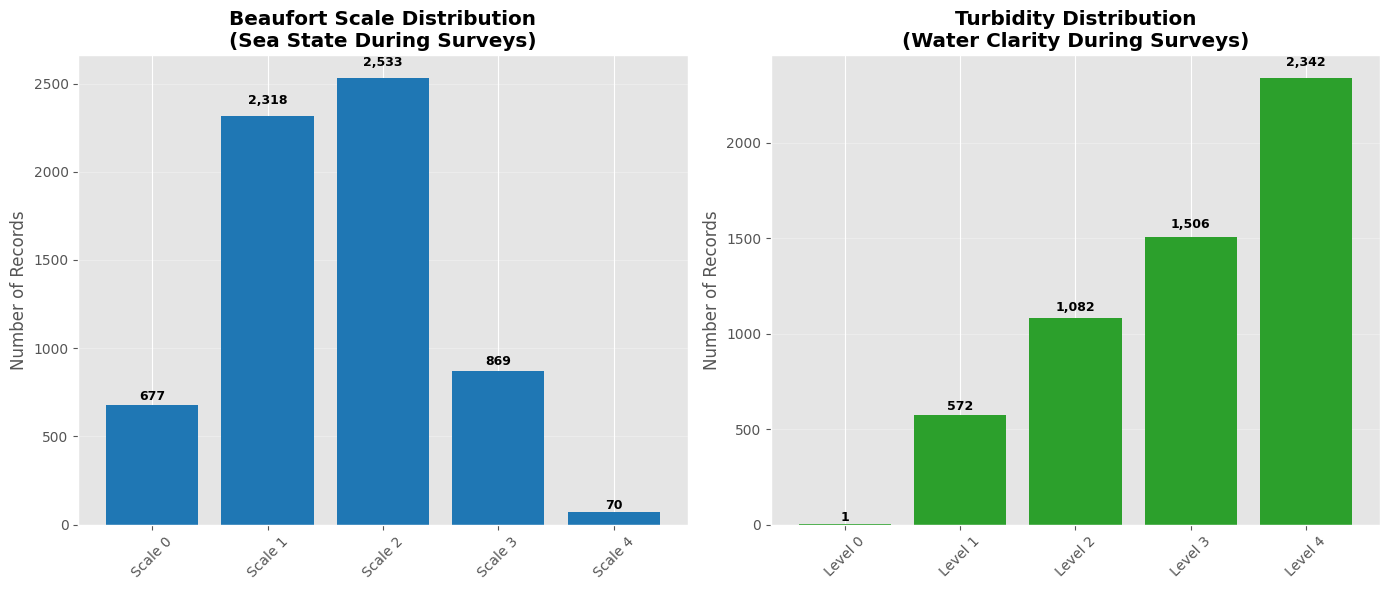

In [6]:
# Survey conditions analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Beaufort Scale Distribution
beaufort_counts = (
    df.drop_nulls("beaufortScale")
    .group_by("beaufortScale")
    .agg(pl.count().alias("count"))
    .sort("beaufortScale")
    .to_pandas()
)
beaufort_counts['beaufortScale'] = beaufort_counts['beaufortScale'].astype(str)

ax1.bar(
    [f"Scale {b}" for b in beaufort_counts['beaufortScale']],
    beaufort_counts['count'],
    color='#1f77b4'
)
ax1.set_title("Beaufort Scale Distribution\n(Sea State During Surveys)", fontweight='bold')
ax1.set_ylabel("Number of Records")
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for i, (_, row) in enumerate(beaufort_counts.iterrows()):
    ax1.text(i, row['count'] + (row['count'] * 0.02), f'{int(row["count"]):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Turbidity Distribution
turbidity_counts = (
    df.drop_nulls("turbidityScale")
    .group_by("turbidityScale")
    .agg(pl.count().alias("count"))
    .sort("turbidityScale")
    .to_pandas()
)
turbidity_counts['turbidityScale'] = turbidity_counts['turbidityScale'].astype(str)

ax2.bar(
    [f"Level {t}" for t in turbidity_counts['turbidityScale']],
    turbidity_counts['count'],
    color='#2ca02c'
)
ax2.set_title("Turbidity Distribution\n(Water Clarity During Surveys)", fontweight='bold')
ax2.set_ylabel("Number of Records")
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for i, (_, row) in enumerate(turbidity_counts.iterrows()):
    ax2.text(i, row['count'] + (row['count'] * 0.02), f'{int(row["count"]):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Regional Population Distribution (H3 Resolution 4)
This section visualises the spatial distribution of dugong sightings using the pre-computed H3 spatial index (Resolution 4, ~1,770 km² hexagons). This coarser resolution provides a broad overview of population hotspots across Australian coastal waters.

Population counts are aggregated per hexagon and displayed using a vibrant colour gradient to distinguish density variations, even for small counts (1-5 individuals).

In [7]:
# Use the pre-computed h3Index (Resolution 4) from the dataset
h3_density_res4 = (
    df.group_by("h3Index")
    .agg(
        pl.len().alias("n_records"),
        pl.col("organismQuantity").sum().alias("total_dugongs")
    )
    .drop_nulls("h3Index")
)

print(f"Generated {len(h3_density_res4)} spatial hexes (Resolution 4)")
print(f"Population range: {h3_density_res4['total_dugongs'].min()} - {h3_density_res4['total_dugongs'].max()} dugongs per hex")

# Generate H3 hexagon layers using util function
layers_res4 = util.generate_pydeck_hexagon_layers(
    df=h3_density_res4,
    aggregate_column_name="total_dugongs",
    hexagon_index_column_name="h3Index",
    n_quantiles=10,
    color_palette="viridis",
)

# Initialize view over Northern Australia
view_state_res4 = pdk.ViewState(latitude=-18.5, longitude=140.0, zoom=4, pitch=0)

map_res4 = pdk.Deck(
    layers=layers_res4, 
    initial_view_state=view_state_res4, 
    tooltip={
        "html": """
            <div style="font-family: 'Helvetica Neue', Arial, sans-serif; padding: 10px;">
                <b style="font-size: 1.2em;">H3 Index:</b> <code>{h3Index}</code><br/>
                <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
                <b>Records:</b> {n_records}<br/>
                <b>Total Dugongs:</b> {total_dugongs}
            </div>
        """,
        "style": {
            "width": "33%",
            "backgroundColor": "#2b2b2b",
            "color": "white",
            "borderRadius": "4px",
            "zIndex": "1000"
        }
    },
    map_style=pdk.map_styles.LIGHT_NO_LABELS,
)
map_res4.show()

Generated 218 spatial hexes (Resolution 4)
Population range: 1 - 2225 dugongs per hex


## 7. High-Resolution Density Mapping (H3 Resolution 6)
For finer-grained spatial analysis, this section computes H3 hexagons at Resolution 6 (~36 km² hexagons) from raw coordinates. This higher resolution identifies localised dugong congregation areas and potential critical habitats with greater precision.

In [8]:
# Compute Resolution 6 hexes for detailed view using polars_h3
df_h3_res6 = df.with_columns(
    polars_h3.latlng_to_cell(
        lat=pl.col("decimalLatitude"),
        lng=pl.col("decimalLongitude"),
        resolution=6,
        return_dtype=pl.String,
    ).alias("h3Index_6")
)

# Aggregate population counts at Resolution 6
h3_density_res6 = (
    df_h3_res6.group_by("h3Index_6")
    .agg(
        pl.len().alias("n_records"),
        pl.col("organismQuantity").sum().alias("total_dugongs")
    )
    .drop_nulls("h3Index_6")
)

print(f"Generated {len(h3_density_res6)} spatial hexes (Resolution 6)")
print(f"Population range: {h3_density_res6['total_dugongs'].min()} - {h3_density_res6['total_dugongs'].max()} dugongs per hex")

# Generate H3 hexagon layers using util function
layers_res6 = util.generate_pydeck_hexagon_layers(
    df=h3_density_res6,
    aggregate_column_name="total_dugongs",
    hexagon_index_column_name="h3Index_6",
    n_quantiles=10,
    color_palette="viridis",
)

# Zoom in for detailed view
view_state_res6 = pdk.ViewState(latitude=-18.5, longitude=146.0, zoom=6, pitch=0)

map_res6 = pdk.Deck(
    layers=layers_res6,
    initial_view_state=view_state_res6,
    tooltip={
        "html": """
            <div style="font-family: 'Helvetica Neue', Arial, sans-serif; padding: 10px;">
                <b style="font-size: 1.2em;">H3 Index:</b> <code>{h3Index_6}</code><br/>
                <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
                <b>Records:</b> {n_records}<br/>
                <b>Total Dugongs:</b> {total_dugongs}
            </div>
        """,
        "style": {
            "width": "33%",
            "backgroundColor": "#2b2b2b",
            "color": "white",
            "borderRadius": "4px",
            "zIndex": "1000"
        }
    },
    map_style=pdk.map_styles.LIGHT_NO_LABELS,
)
map_res6.show()

Generated 1952 spatial hexes (Resolution 6)
Population range: 1 - 851 dugongs per hex


## 8. Habitat Distribution by Marine Region
To establish spatial context, population distributions are quantified across designated Australian Marine Regions. 

The interactive viewer below outlines the established marine boundaries. Following this, historical sightings are aggregated to highlight the regions sustaining the highest population densities. The chart isolates the top 15 most populated marine regions for analytical clarity.

In [9]:
# Display the Commonwealth Marine Regions for spatial reference
IPython.display.IFrame(
    src="https://fed.dcceew.gov.au/datasets/commonwealth-marine-regions/explore?location=-33.665700%2C140.517300%2C4",
    width="100%", 
    height="600px",
)

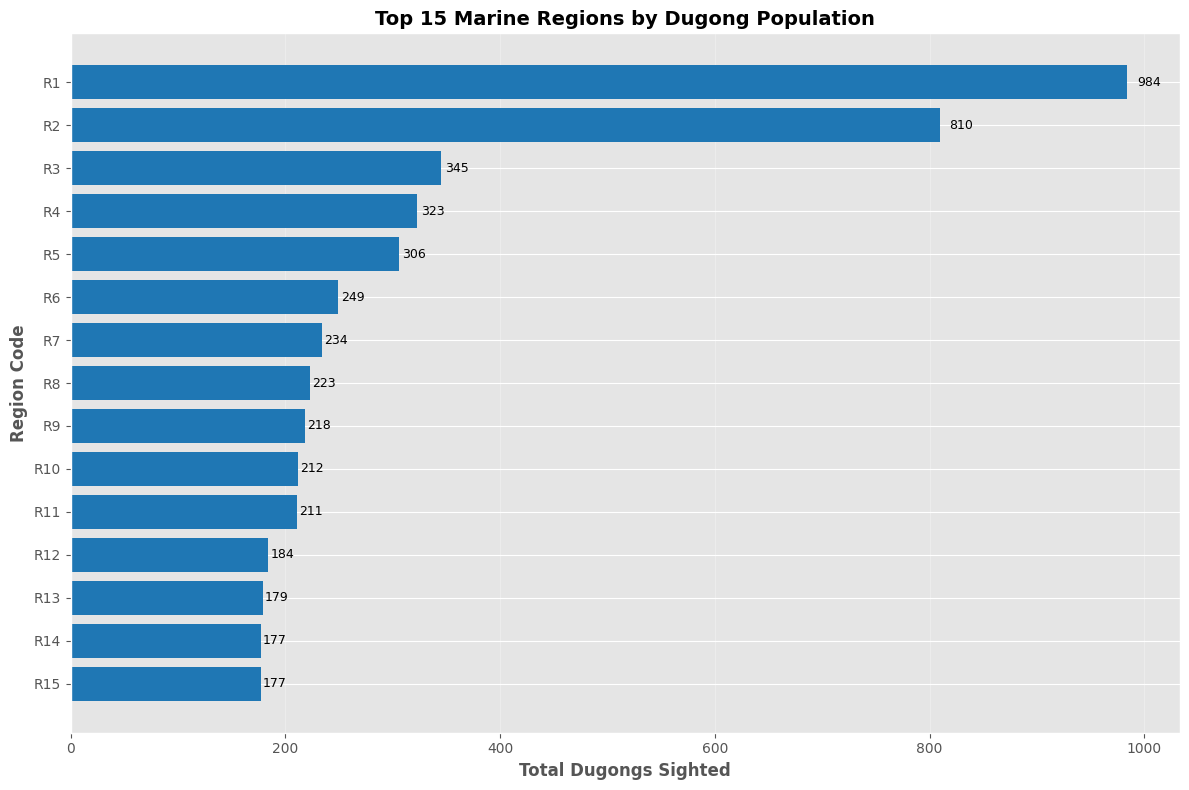


--- Marine Region Reference Guide ---


Code,Marine Region,Total Sighted
R1,IMCRA:Provincial:Name:Central Eastern Shelf Transition|IMCRA:Mesoscale:Name:Tweed-Moreton|IMCRA:Mesoscale:Water Type:Transitional Waters|IMCRA:Provincial:Water Type:Transitional Waters,984
R2,IMCRA:Mesoscale:Water Type:Transitional Waters|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Provincial:Name:Central Eastern Shelf Transition|IMCRA:Mesoscale:Name:Tweed-Moreton,810
R3,IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Mesoscale:Name:East Cape York|IMCRA:Mesoscale:Water Type:Transitional Waters|World Heritage Area:Great Barrier Reef,345
R4,IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Mesoscale:Name:Tweed-Moreton|IMCRA:Provincial:Name:Central Eastern Shelf Transition|IMCRA:Mesoscale:Water Type:Transitional Waters,323
R5,IMCRA:Mesoscale:Name:Tweed-Moreton|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Provincial:Name:Central Eastern Shelf Transition|IMCRA:Mesoscale:Water Type:Transitional Waters,306
R6,IMCRA:Mesoscale:Name:Torres Strait|IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Mesoscale:Water Type:Transitional Waters,249
R7,IMCRA:Mesoscale:Water Type:Transitional Waters|IMCRA:Provincial:Water Type:Transitional Waters|World Heritage Area:Great Barrier Reef|IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Mesoscale:Name:East Cape York,234
R8,IMCRA:Mesoscale:Water Type:Transitional Waters|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Mesoscale:Name:Torres Strait,223
R9,IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Mesoscale:Name:Torres Strait|IMCRA:Mesoscale:Water Type:Transitional Waters,218
R10,IMCRA:Provincial:Name:Northeast Shelf Transition|IMCRA:Provincial:Water Type:Transitional Waters|IMCRA:Mesoscale:Water Type:Transitional Waters|IMCRA:Mesoscale:Name:Torres Strait,212


In [10]:
# Safely parse, explode, and aggregate the marine tags
regional_counts = (
    df.with_columns(
        pl.col("australianMarineRegionsTags").cast(pl.String).str.split(",")
    )
    .explode("australianMarineRegionsTags")
    .with_columns(pl.col("australianMarineRegionsTags").str.strip_chars())
    .drop_nulls("australianMarineRegionsTags")
    .filter(
        (pl.col("australianMarineRegionsTags") != "") & 
        (pl.col("australianMarineRegionsTags") != "null")
    )
    .group_by("australianMarineRegionsTags")
    .agg(pl.col("organismQuantity").sum().alias("total_dugongs"))
    .sort("total_dugongs", descending=True)
    .head(15)  # Top 15 regions
).to_pandas()

# Create short codes for each region (R1, R2, R3, etc.)
regional_counts['code'] = [f"R{i+1}" for i in range(len(regional_counts))]

# Create horizontal bar chart with solid colour
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    regional_counts['code'][::-1],  # Reverse for largest at top
    regional_counts['total_dugongs'][::-1],
    color='#1f77b4'
)

ax.set_xlabel("Total Dugongs Sighted", fontweight='bold')
ax.set_ylabel("Region Code", fontweight='bold')
ax.set_title("Top 15 Marine Regions by Dugong Population", fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + (width * 0.01), bar.get_y() + bar.get_height()/2, 
            f'{int(width):,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Display reference table with codes and full region names
print("\n--- Marine Region Reference Guide ---")
reference_df = regional_counts[['code', 'australianMarineRegionsTags', 'total_dugongs']].rename(
    columns={'code': 'Code', 'australianMarineRegionsTags': 'Marine Region', 'total_dugongs': 'Total Sighted'}
)
IPython.display.display(reference_df.style.hide(axis='index'))

### Spatial Visualisation of Marine Region Populations
The map below displays dugong population density by marine region, providing a geographic context for the bar chart above. Regions with higher populations are shown in warmer colours.

In [11]:
# Create a map showing dugong sighting locations colored by marine region
# Use actual sighting points with H3 hexes colored by dominant marine region

# Get unique H3 hexes with their marine regions and population
h3_by_region = (
    df.with_columns(
        pl.col("australianMarineRegionsTags").cast(pl.String).str.split("|")
    )
    .explode("australianMarineRegionsTags")
    .with_columns(pl.col("australianMarineRegionsTags").str.strip_chars())
    .drop_nulls(["h3Index", "australianMarineRegionsTags"])
    .filter(
        (pl.col("australianMarineRegionsTags") != "") & 
        (pl.col("australianMarineRegionsTags") != "null")
    )
    .group_by("h3Index")
    .agg([
        pl.col("organismQuantity").sum().alias("total_dugongs"),
        pl.col("australianMarineRegionsTags").first().alias("marine_region")
    ])
).to_pandas()

# Create a color mapping for marine regions using tab20 colormap
unique_regions = h3_by_region['marine_region'].unique()
region_colors = {region: list(cm.tab20(i % 20)[:3]) for i, region in enumerate(unique_regions)}

# Convert to RGB 0-255
h3_by_region['color'] = h3_by_region['marine_region'].apply(
    lambda r: [int(c * 255) for c in region_colors.get(r, [0.5, 0.5, 0.5])]
)

print(f"Displaying {len(h3_by_region)} hexes across {len(unique_regions)} marine regions")

# Render with H3HexagonLayer
region_layer = pdk.Layer(
    "H3HexagonLayer",
    h3_by_region,
    pickable=True,
    stroked=True,
    filled=True,
    extruded=False,
    get_hexagon="h3Index",
    get_fill_color="color",
    get_line_color=[255, 255, 255],
    line_width_min_pixels=1,
    opacity=0.8
)

# Use util function to compute view state based on data
region_view = util.generate_view_state(
    df=df,
    view_proportion=1.0,
    longitude_column_name="decimalLongitude",
    latitude_column_name="decimalLatitude",
)

region_map = pdk.Deck(
    layers=[region_layer],
    initial_view_state=region_view,
    tooltip={
        "html": """
            <div style="font-family: 'Helvetica Neue', Arial, sans-serif; padding: 10px;">
                <b style="font-size: 1.2em;">H3 Index:</b> <code>{h3Index}</code><br/>
                <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
                <b>Marine Region:</b> {marine_region}<br/>
                <b>Total Dugongs:</b> {total_dugongs}
            </div>
        """,
        "style": {
            "width": "33%",
            "backgroundColor": "#2b2b2b",
            "color": "white",
            "borderRadius": "4px",
            "zIndex": "1000"
        }
    },
    map_style=pdk.map_styles.LIGHT_NO_LABELS,
)
region_map.show()

Displaying 211 hexes across 31 marine regions


## 9: Total Dugong Population by H3 Cell 

Compute total animals per coordinate by summing adults and calves grouped by lat/lon, then aggregate into H3 cells (Resolution 4) for spatial visualisation.


In [12]:
# Sum adults + calves per coordinate
total_per_coord = (
    df.filter(pl.col("organismQuantityType").is_in(["adult", "calves"]))
    .group_by(["decimalLatitude", "decimalLongitude", "h3Index"])
    .agg(pl.col("organismQuantity").sum().alias("total_animals"))
    .drop_nulls("h3Index")
)

# Aggregate by H3 cell
h3_total = (
    total_per_coord.group_by("h3Index")
    .agg(
        pl.len().alias("n_records"),
        pl.col("total_animals").sum().alias("total_dugongs")
    )
)

print(f"Total dugong population map: {len(h3_total)} H3 cells (Resolution 4)")
print(f"Population range: {h3_total['total_dugongs'].min()} - {h3_total['total_dugongs'].max()} dugongs per cell")

# Generate H3 hexagon layers using util function
layers_total = util.generate_pydeck_hexagon_layers(
    df=h3_total,
    aggregate_column_name="total_dugongs",
    hexagon_index_column_name="h3Index",
    n_quantiles=10,
    color_palette="viridis",
)

view_state_total = pdk.ViewState(latitude=-18.5, longitude=140.0, zoom=4, pitch=0)

map_total = pdk.Deck(
    layers=layers_total,
    initial_view_state=view_state_total,
    tooltip={
        "html": """
            <div style="font-family: 'Helvetica Neue', Arial, sans-serif; padding: 10px;">
                <b style="font-size: 1.2em;">H3 Index:</b> <code>{h3Index}</code><br/>
                <hr style="margin: 5px 0; border: 0; border-top: 1px solid #ccc;">
                <b>Records:</b> {n_records}<br/>
                <b>Total Dugongs:</b> {total_dugongs}
            </div>
        """,
        "style": {
            "width": "33%",
            "backgroundColor": "#2b2b2b",
            "color": "white",
            "borderRadius": "4px",
            "zIndex": "1000"
        }
    },
    map_style=pdk.map_styles.LIGHT_NO_LABELS,
)
map_total.show()

Total dugong population map: 218 H3 cells (Resolution 4)
Population range: 1 - 2225 dugongs per cell
